# 05 - EDA + Kaplan–Meier

Mục tiêu:
- mô tả quy mô cohort;
- tỷ lệ resolved/censored;
- phân bố time-to-resolution;
- Kaplan–Meier toàn bộ;
- Kaplan–Meier theo priority / issue type.

Trong bài toán này:

**S(t) = P(issue vẫn chưa được resolve sau t ngày).**

In [2]:
from pathlib import Path
import sys, yaml, pandas as pd, numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

with open(ROOT / "configs" / "experiment.yaml", "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

print("ROOT =", ROOT)
print("random_seed =", CFG["random_seed"])

ROOT = d:\VNUK\Eureka 2026\Eureka_2026
random_seed = 42


In [3]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

cohort = pd.read_parquet(ROOT / "data" / "processed" / "cohort.parquet")
fig_dir = ROOT / "results" / "figures"
table_dir = ROOT / "results" / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

print("Rows:", len(cohort))
print("Projects:", cohort["project"].nunique())
print("Repositories:", cohort["repository"].nunique())
print("Resolved:", int(cohort["event"].sum()))
print("Censored:", int((~cohort["event"]).sum()))
print("Censoring rate:", float((~cohort["event"]).mean()))
print("Median observed duration:", float(cohort["duration_days"].median()))

Rows: 835643
Projects: 12
Repositories: 8
Resolved: 751889
Censored: 83754
Censoring rate: 0.1002270108168201
Median observed duration: 7.208668981481481


In [4]:
project_stats = (
    cohort.groupby(["repository", "project"])
    .agg(
        issues=("issue_key", "size"),
        resolved=("event", "sum"),
        median_duration_days=("duration_days", "median"),
    )
    .reset_index()
)
project_stats["unresolved"] = project_stats["issues"] - project_stats["resolved"]
project_stats["censoring_rate"] = project_stats["unresolved"] / project_stats["issues"]

project_stats.to_csv(table_dir / "eda_project_stats.csv", index=False)
project_stats.sort_values("issues", ascending=False).head(30)

,repository,project,issues,resolved,median_duration_days,unresolved,censoring_rate
6,Mojang,MC,213845,205547,0.177396,8298,0.038804
7,Mojang,MCPE,144778,140317,1.122054,4461,0.030813
9,Qt,QTBUG,97172,77520,110.856227,19652,0.202239
11,Sonatype,OSSRH,74960,72193,0.291748,2767,0.036913
8,MongoDB,SERVER,58928,52972,22.137760,5956,0.101072
4,Jira,JRASERVER,47225,38678,426.490706,8547,0.180985
2,Jira,CONFSERVER,43910,37290,443.209896,6620,0.150763
10,Sakai,SAK,43351,39086,32.218113,4265,0.098383
0,Apache,FLEX,35390,31564,132.300249,3826,0.108110
3,Jira,JRACLOUD,27916,22142,805.739039,5774,0.206835


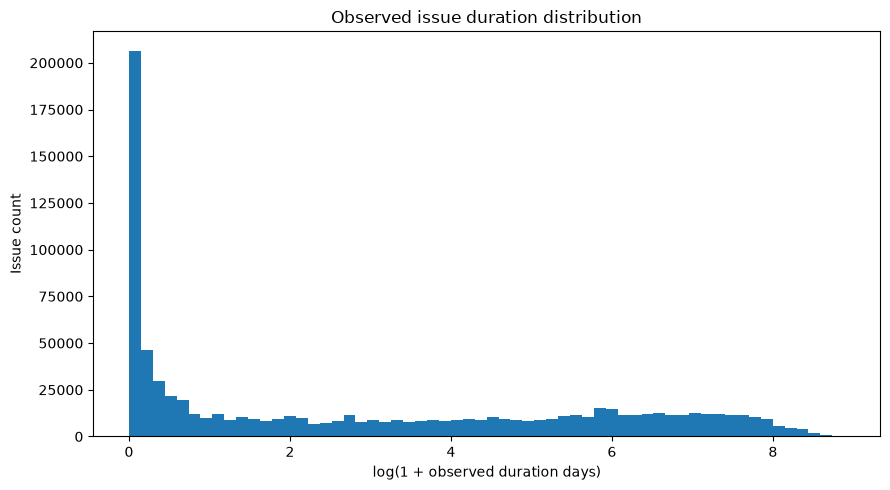

In [5]:
# Duration distribution: dùng log1p để nhìn rõ đuôi dài.
plt.figure(figsize=(9, 5))
plt.hist(np.log1p(cohort["duration_days"]), bins=60)
plt.xlabel("log(1 + observed duration days)")
plt.ylabel("Issue count")
plt.title("Observed issue duration distribution")
plt.tight_layout()
plt.savefig(fig_dir / "duration_distribution_log.png", dpi=200)
plt.show()

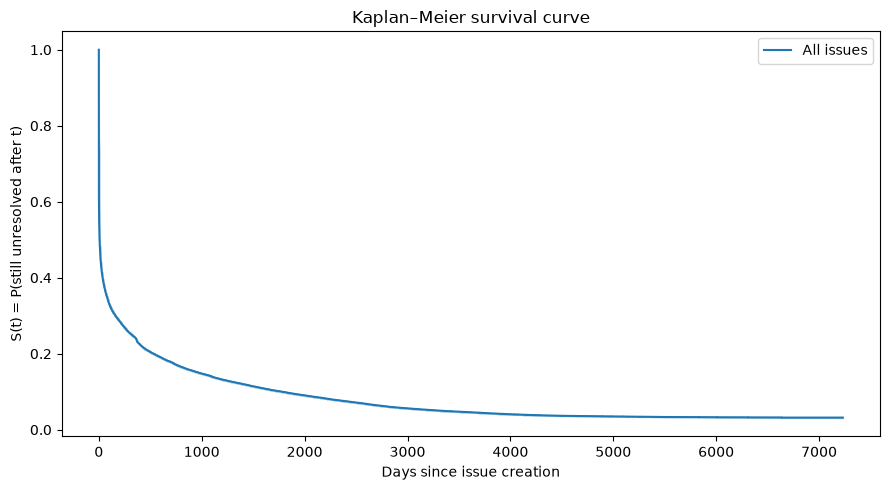

In [6]:
kmf = KaplanMeierFitter()
kmf.fit(
    durations=cohort["duration_days"],
    event_observed=cohort["event"],
    label="All issues",
)

plt.figure(figsize=(9, 5))
kmf.plot_survival_function()
plt.xlabel("Days since issue creation")
plt.ylabel("S(t) = P(still unresolved after t)")
plt.title("Kaplan–Meier survival curve")
plt.tight_layout()
plt.savefig(fig_dir / "km_overall.png", dpi=200)
plt.show()

km_table = pd.DataFrame({
    "timeline": kmf.survival_function_.index,
    "survival_probability": kmf.survival_function_.iloc[:, 0].values,
})
km_table.to_csv(table_dir / "km_overall.csv", index=False)

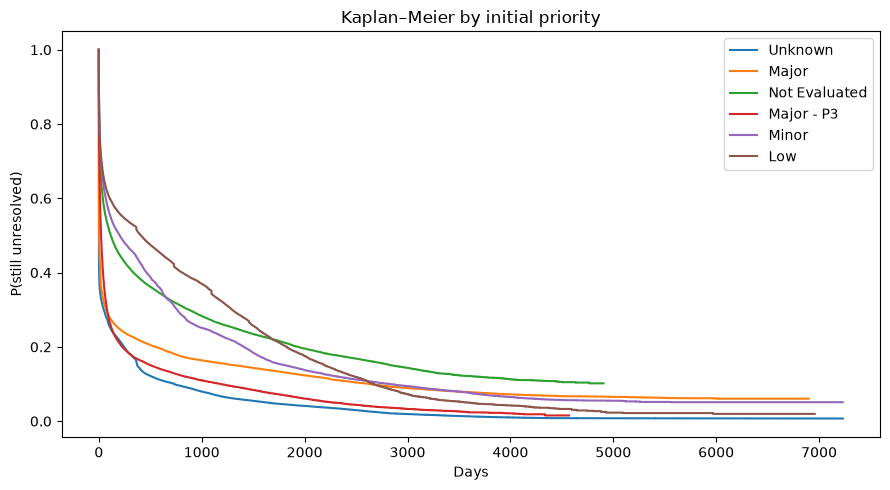

In [7]:
# Top priority groups đủ lớn.
priority_counts = cohort["initial_priority"].fillna("Unknown").value_counts()
top_priorities = priority_counts.head(6).index

plt.figure(figsize=(9, 5))
for priority in top_priorities:
    mask = cohort["initial_priority"].fillna("Unknown") == priority
    if mask.sum() < 100:
        continue
    km = KaplanMeierFitter()
    km.fit(
        cohort.loc[mask, "duration_days"],
        event_observed=cohort.loc[mask, "event"],
        label=str(priority),
    )
    km.plot_survival_function(ci_show=False)

plt.xlabel("Days")
plt.ylabel("P(still unresolved)")
plt.title("Kaplan–Meier by initial priority")
plt.tight_layout()
plt.savefig(fig_dir / "km_priority.png", dpi=200)
plt.show()

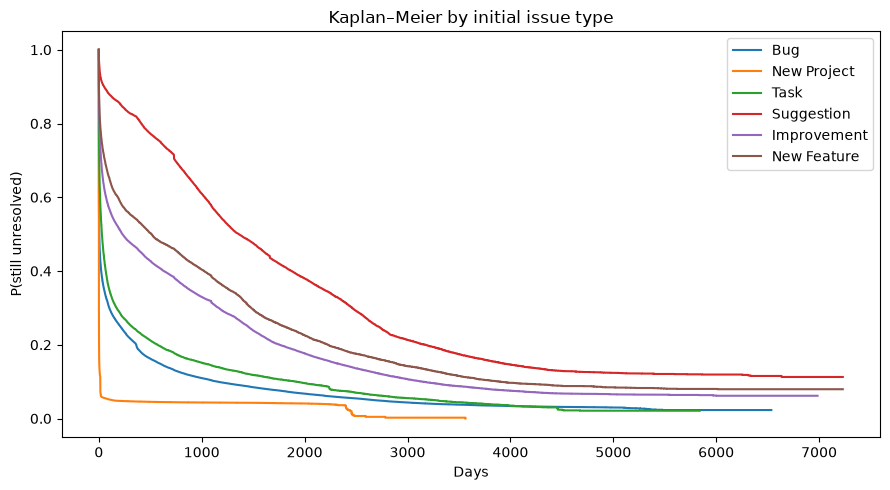

In [8]:
type_counts = cohort["initial_issue_type"].fillna("Unknown").value_counts()
top_types = type_counts.head(6).index

plt.figure(figsize=(9, 5))
for issue_type in top_types:
    mask = cohort["initial_issue_type"].fillna("Unknown") == issue_type
    if mask.sum() < 100:
        continue
    km = KaplanMeierFitter()
    km.fit(
        cohort.loc[mask, "duration_days"],
        event_observed=cohort.loc[mask, "event"],
        label=str(issue_type),
    )
    km.plot_survival_function(ci_show=False)

plt.xlabel("Days")
plt.ylabel("P(still unresolved)")
plt.title("Kaplan–Meier by initial issue type")
plt.tight_layout()
plt.savefig(fig_dir / "km_issue_type.png", dpi=200)
plt.show()

Không diễn giải Kaplan–Meier như quan hệ nhân quả.  
Đây là mô tả khác biệt survival giữa các nhóm.